# Project 3: Multi-Agent Reinforcement Learning - Predator-Prey

**Author:** Milan Amrut Joshi

## Overview
This notebook implements a **Multi-Agent RL** system for a predator-prey grid world:
- **2 predators** must cooperate to capture **1 prey**
- Each predator uses **Independent Q-Learning (IQL)** -- treating other agents as part of the environment
- The prey follows a simple escape heuristic

We analyze:
1. How capture rates improve over training
2. Whether implicit cooperation emerges between independent learners
3. Cooperative vs independent strategies in multi-agent settings

## 1. Multi-Agent RL Background

### Independent Q-Learning (IQL)
Each agent $i$ maintains its own Q-table $Q_i(s, a_i)$ and updates it independently:

$$Q_i(s, a_i) \leftarrow Q_i(s, a_i) + \alpha [r_i + \gamma \max_{a_i'} Q_i(s', a_i') - Q_i(s, a_i)]$$

The key challenge is that from each agent's perspective, the environment is **non-stationary**
because other agents are simultaneously learning and changing their policies.

### Predator-Prey Game
- **Grid:** $N \times N$ toroidal grid (wraps around)
- **Capture condition:** A predator occupies the same cell as the prey
- **Cooperative reward:** Both predators get reward when either captures the prey
- **State:** Relative positions of prey from each predator's perspective

## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

GRID_SIZE = 7
MAX_STEPS = 50          # Max steps per episode
NUM_EPISODES = 5000
ALPHA = 0.2             # Learning rate
GAMMA = 0.95            # Discount factor
EPSILON_START = 1.0     # Initial exploration
EPSILON_END = 0.05
EPSILON_DECAY = 0.998

# Actions: 0=stay, 1=up, 2=down, 3=left, 4=right
ACTION_NAMES = ['Stay', 'Up', 'Down', 'Left', 'Right']
NUM_ACTIONS = 5
# Movement deltas (row, col)
MOVES = [(0, 0), (-1, 0), (1, 0), (0, -1), (0, 1)]

print("Predator-Prey MARL Configuration:")
print(f"  Grid size: {GRID_SIZE}x{GRID_SIZE}")
print(f"  Max steps per episode: {MAX_STEPS}")
print(f"  Training episodes: {NUM_EPISODES}")

Predator-Prey MARL Configuration:
  Grid size: 7x7
  Max steps per episode: 50
  Training episodes: 5000


## 3. Predator-Prey Environment

In [2]:
class PredatorPreyEnv:
    """Grid world with 2 predators and 1 prey."""

    def __init__(self, grid_size=GRID_SIZE):
        self.grid_size = grid_size

    def reset(self):
        """Place agents at random non-overlapping positions."""
        positions = []
        while len(positions) < 3:
            pos = (np.random.randint(self.grid_size), np.random.randint(self.grid_size))
            if pos not in positions:
                positions.append(pos)
        self.pred1_pos = positions[0]
        self.pred2_pos = positions[1]
        self.prey_pos = positions[2]
        return self._get_obs()

    def _wrap(self, pos):
        return (pos[0] % self.grid_size, pos[1] % self.grid_size)

    def _manhattan_dist(self, p1, p2):
        """Toroidal Manhattan distance."""
        dr = min(abs(p1[0] - p2[0]), self.grid_size - abs(p1[0] - p2[0]))
        dc = min(abs(p1[1] - p2[1]), self.grid_size - abs(p1[1] - p2[1]))
        return dr + dc

    def _relative_pos(self, agent_pos, target_pos):
        """Get relative position (wrapped to [-grid//2, grid//2])."""
        dr = (target_pos[0] - agent_pos[0] + self.grid_size // 2) % self.grid_size - self.grid_size // 2
        dc = (target_pos[1] - agent_pos[1] + self.grid_size // 2) % self.grid_size - self.grid_size // 2
        return (dr, dc)

    def _get_obs(self):
        """
        State for each predator: (relative_prey_row, relative_prey_col,
                                   relative_other_pred_row, relative_other_pred_col)
        Discretized to grid offsets.
        """
        prey_rel_1 = self._relative_pos(self.pred1_pos, self.prey_pos)
        other_rel_1 = self._relative_pos(self.pred1_pos, self.pred2_pos)

        prey_rel_2 = self._relative_pos(self.pred2_pos, self.prey_pos)
        other_rel_2 = self._relative_pos(self.pred2_pos, self.pred1_pos)

        obs1 = (prey_rel_1[0], prey_rel_1[1], other_rel_1[0], other_rel_1[1])
        obs2 = (prey_rel_2[0], prey_rel_2[1], other_rel_2[0], other_rel_2[1])
        return obs1, obs2

    def _prey_policy(self):
        """Simple escape heuristic: move away from closest predator."""
        d1 = self._manhattan_dist(self.prey_pos, self.pred1_pos)
        d2 = self._manhattan_dist(self.prey_pos, self.pred2_pos)

        # Choose the closer predator as threat
        threat = self.pred1_pos if d1 <= d2 else self.pred2_pos

        # Move away from threat (with some randomness)
        if np.random.rand() < 0.2:
            return np.random.randint(NUM_ACTIONS)

        rel = self._relative_pos(self.prey_pos, threat)
        # Move opposite to relative direction of threat
        best_actions = []
        if rel[0] > 0:
            best_actions.append(1)  # up (away)
        elif rel[0] < 0:
            best_actions.append(2)  # down
        if rel[1] > 0:
            best_actions.append(3)  # left
        elif rel[1] < 0:
            best_actions.append(4)  # right

        if len(best_actions) == 0:
            return np.random.randint(1, NUM_ACTIONS)
        return np.random.choice(best_actions)

    def step(self, action1, action2):
        """Execute actions and return observations, rewards, done."""
        # Move predators
        m1 = MOVES[action1]
        m2 = MOVES[action2]
        self.pred1_pos = self._wrap((self.pred1_pos[0] + m1[0], self.pred1_pos[1] + m1[1]))
        self.pred2_pos = self._wrap((self.pred2_pos[0] + m2[0], self.pred2_pos[1] + m2[1]))

        # Check capture before prey moves
        captured = (self.pred1_pos == self.prey_pos) or (self.pred2_pos == self.prey_pos)

        if not captured:
            # Move prey
            prey_action = self._prey_policy()
            pm = MOVES[prey_action]
            self.prey_pos = self._wrap((self.prey_pos[0] + pm[0], self.prey_pos[1] + pm[1]))
            # Check capture after prey moves
            captured = (self.pred1_pos == self.prey_pos) or (self.pred2_pos == self.prey_pos)

        obs1, obs2 = self._get_obs()

        if captured:
            return obs1, obs2, 10.0, True

        # Small penalty per step to encourage faster capture
        return obs1, obs2, -0.1, False


env = PredatorPreyEnv()
obs = env.reset()
print(f"Predator 1 observation shape: {len(obs[0])} values (relative positions)")
print(f"Sample obs: pred1={obs[0]}, pred2={obs[1]}")

Predator 1 observation shape: 4 values (relative positions)
Sample obs: pred1=(3, 1, -2, 3), pred2=(-2, -2, 2, -3)


## 4. Independent Q-Learning Agents

In [3]:
class IQLAgent:
    """Independent Q-Learning agent using a hash-based Q-table."""

    def __init__(self, num_actions=NUM_ACTIONS, alpha=ALPHA, gamma=GAMMA):
        self.num_actions = num_actions
        self.alpha = alpha
        self.gamma = gamma
        self.q_table = {}

    def _get_q(self, state):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.num_actions)
        return self.q_table[state]

    def get_action(self, state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.randint(self.num_actions)
        q = self._get_q(state)
        return np.argmax(q)

    def update(self, state, action, reward, next_state, done):
        q = self._get_q(state)
        q_next = self._get_q(next_state)
        target = reward + (0 if done else self.gamma * np.max(q_next))
        q[action] += self.alpha * (target - q[action])


# Create agents
agent1 = IQLAgent()
agent2 = IQLAgent()

# Training
epsilon = EPSILON_START
capture_history = []
reward_history = []
steps_history = []

for ep in range(NUM_EPISODES):
    obs1, obs2 = env.reset()
    total_reward = 0.0
    captured = False

    for step in range(MAX_STEPS):
        a1 = agent1.get_action(obs1, epsilon)
        a2 = agent2.get_action(obs2, epsilon)

        next_obs1, next_obs2, reward, done = env.step(a1, a2)

        agent1.update(obs1, a1, reward, next_obs1, done)
        agent2.update(obs2, a2, reward, next_obs2, done)

        total_reward += reward
        obs1, obs2 = next_obs1, next_obs2

        if done:
            captured = True
            break

    capture_history.append(1 if captured else 0)
    reward_history.append(total_reward)
    steps_history.append(step + 1)
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

print(f"Training complete!")
print(f"  Q-table sizes: Agent1={len(agent1.q_table)}, Agent2={len(agent2.q_table)}")
print(f"  Final epsilon: {epsilon:.4f}")
print(f"  Overall capture rate: {np.mean(capture_history):.4f}")

Training complete!
  Q-table sizes: Agent1=2378, Agent2=2378
  Final epsilon: 0.0500
  Overall capture rate: 0.8986


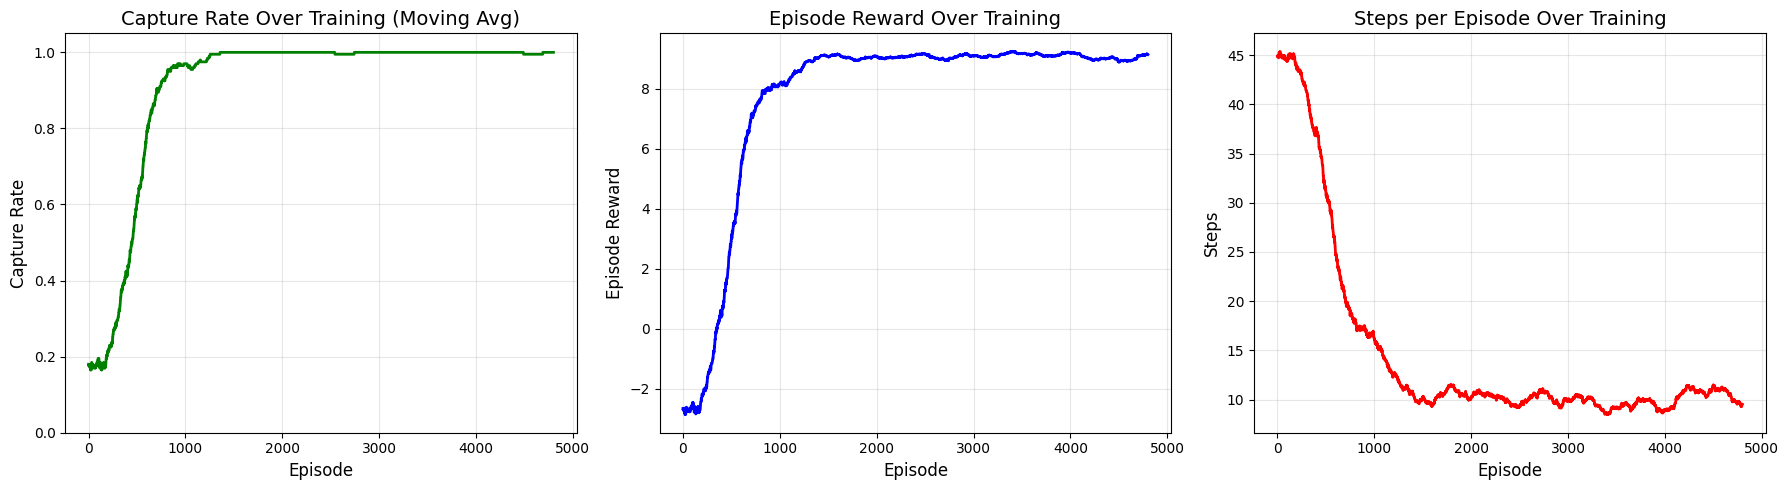

In [4]:
# Smooth and plot training metrics
def moving_average(data, window=100):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Capture rate
cap_smooth = moving_average(capture_history, 200)
axes[0].plot(cap_smooth, 'g-', linewidth=2)
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Capture Rate', fontsize=12)
axes[0].set_title('Capture Rate Over Training (Moving Avg)', fontsize=14)
axes[0].set_ylim([0, 1.05])
axes[0].grid(True, alpha=0.3)

# Reward
rew_smooth = moving_average(reward_history, 200)
axes[1].plot(rew_smooth, 'b-', linewidth=2)
axes[1].set_xlabel('Episode', fontsize=12)
axes[1].set_ylabel('Episode Reward', fontsize=12)
axes[1].set_title('Episode Reward Over Training', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Steps to capture
steps_smooth = moving_average(steps_history, 200)
axes[2].plot(steps_smooth, 'r-', linewidth=2)
axes[2].set_xlabel('Episode', fontsize=12)
axes[2].set_ylabel('Steps', fontsize=12)
axes[2].set_title('Steps per Episode Over Training', fontsize=14)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Visualization: Grid World and Trajectories

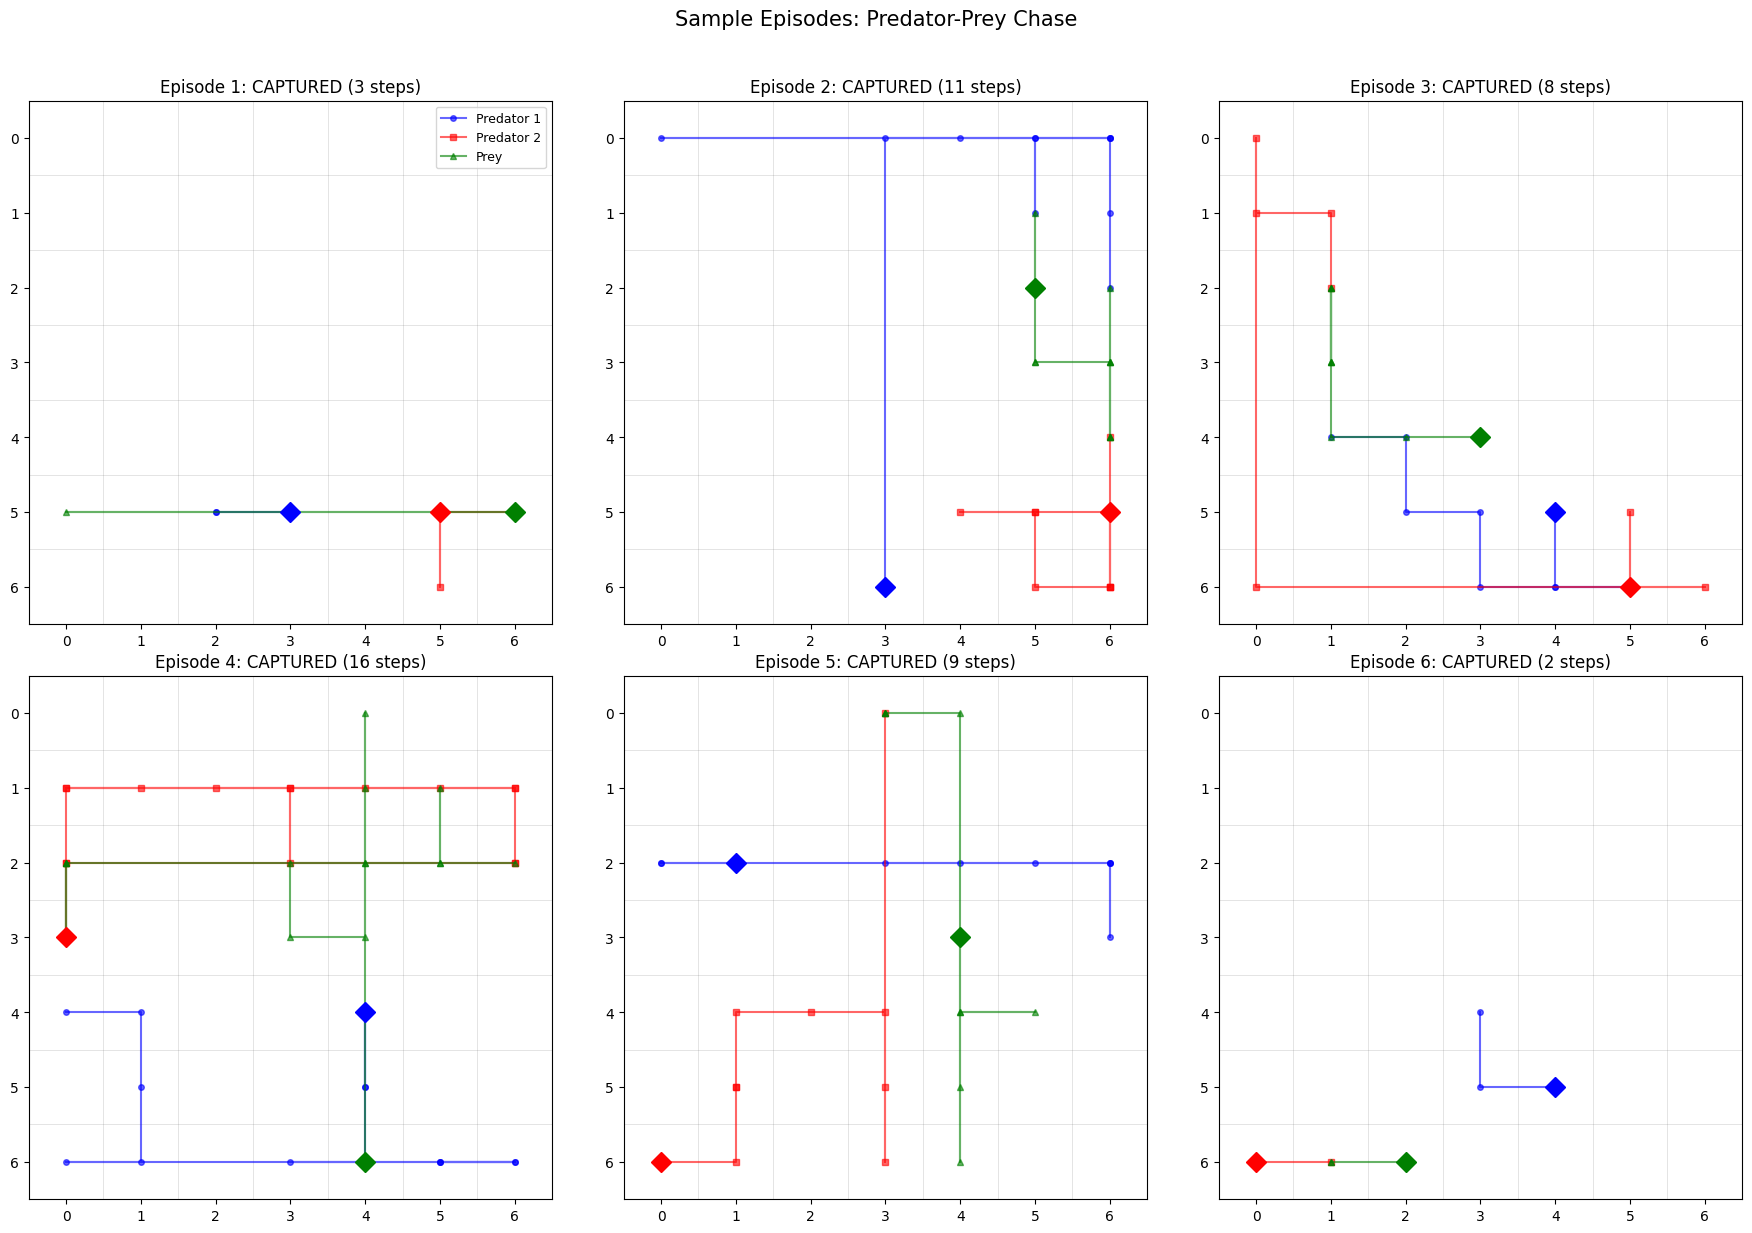

In [5]:
def visualize_episode(env, agent1, agent2, max_steps=30):
    """Run and visualize a single episode."""
    obs1, obs2 = env.reset()
    trajectory = {
        'pred1': [env.pred1_pos],
        'pred2': [env.pred2_pos],
        'prey': [env.prey_pos]
    }

    for step in range(max_steps):
        a1 = agent1.get_action(obs1, epsilon=0.0)
        a2 = agent2.get_action(obs2, epsilon=0.0)
        obs1, obs2, reward, done = env.step(a1, a2)
        trajectory['pred1'].append(env.pred1_pos)
        trajectory['pred2'].append(env.pred2_pos)
        trajectory['prey'].append(env.prey_pos)
        if done:
            break

    return trajectory, done


# Run a few episodes and visualize
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for idx in range(6):
    ax = axes[idx // 3][idx % 3]
    traj, captured = visualize_episode(env, agent1, agent2)

    # Draw grid
    for i in range(GRID_SIZE + 1):
        ax.axhline(y=i - 0.5, color='gray', linewidth=0.5, alpha=0.3)
        ax.axvline(x=i - 0.5, color='gray', linewidth=0.5, alpha=0.3)

    # Plot trajectories
    p1 = np.array(traj['pred1'])
    p2 = np.array(traj['pred2'])
    pr = np.array(traj['prey'])

    ax.plot(p1[:, 1], p1[:, 0], 'b-o', markersize=4, alpha=0.6, label='Predator 1')
    ax.plot(p2[:, 1], p2[:, 0], 'r-s', markersize=4, alpha=0.6, label='Predator 2')
    ax.plot(pr[:, 1], pr[:, 0], 'g-^', markersize=4, alpha=0.6, label='Prey')

    # Mark start and end
    ax.plot(p1[0, 1], p1[0, 0], 'bD', markersize=10)
    ax.plot(p2[0, 1], p2[0, 0], 'rD', markersize=10)
    ax.plot(pr[0, 1], pr[0, 0], 'gD', markersize=10)

    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    ax.set_ylim(-0.5, GRID_SIZE - 0.5)
    ax.set_aspect('equal')
    result = "CAPTURED" if captured else "ESCAPED"
    ax.set_title(f'Episode {idx+1}: {result} ({len(traj["pred1"])-1} steps)', fontsize=12)
    ax.invert_yaxis()
    if idx == 0:
        ax.legend(fontsize=9, loc='upper right')

plt.suptitle('Sample Episodes: Predator-Prey Chase', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 6. Cooperation Analysis

Let us analyze whether cooperation emerges by looking at:
- Distance between predators when capture occurs
- Coordination patterns (approaching prey from different directions)

Capture analysis (500 captures out of 500 episodes):
  Mean distance between predators at capture: 2.55
  Fraction approaching from different sides: 1.00


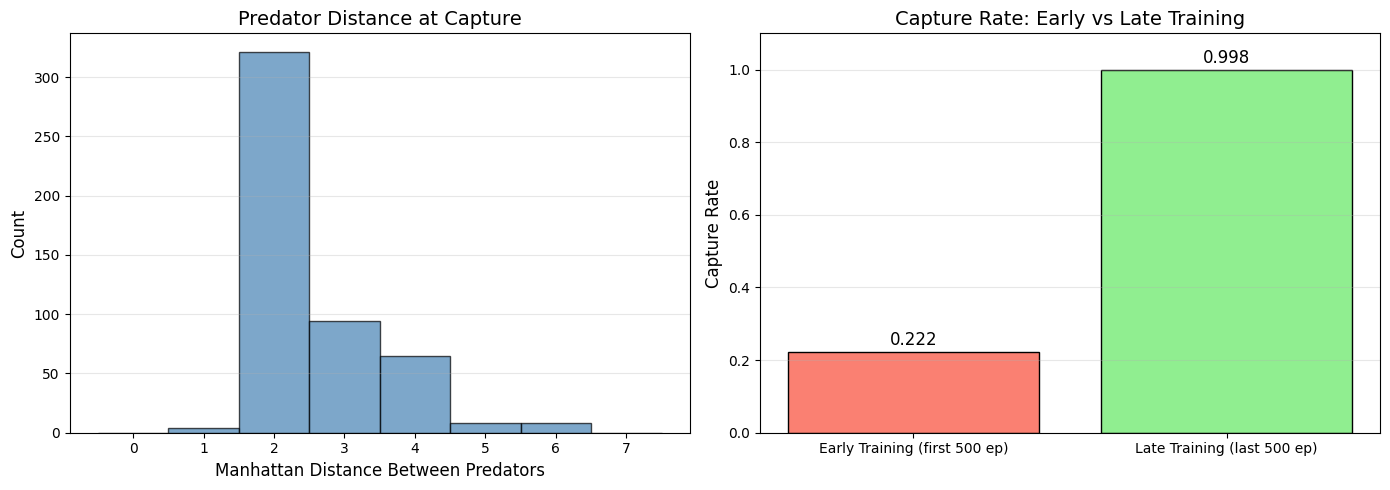

In [6]:
# Analyze cooperation patterns
capture_distances = []  # Distance between predators at capture
approach_angles = []     # Whether predators approach from different sides

num_analysis = 500
for _ in range(num_analysis):
    obs1, obs2 = env.reset()
    for step in range(MAX_STEPS):
        a1 = agent1.get_action(obs1, epsilon=0.0)
        a2 = agent2.get_action(obs2, epsilon=0.0)
        obs1, obs2, reward, done = env.step(a1, a2)

        if done:
            d = env._manhattan_dist(env.pred1_pos, env.pred2_pos)
            capture_distances.append(d)
            # Check if approaching from different sides
            rel1 = env._relative_pos(env.prey_pos, env.pred1_pos)
            rel2 = env._relative_pos(env.prey_pos, env.pred2_pos)
            # Different sides if relative positions are in opposite directions
            same_side = (np.sign(rel1[0]) == np.sign(rel2[0])) and (np.sign(rel1[1]) == np.sign(rel2[1]))
            approach_angles.append(0 if same_side else 1)
            break

print(f"Capture analysis ({len(capture_distances)} captures out of {num_analysis} episodes):")
print(f"  Mean distance between predators at capture: {np.mean(capture_distances):.2f}")
print(f"  Fraction approaching from different sides: {np.mean(approach_angles):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(capture_distances, bins=range(GRID_SIZE + 2), align='left',
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Manhattan Distance Between Predators', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Predator Distance at Capture', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')

# Cooperation over training: compare early vs late episodes
early_cap = np.mean(capture_history[:500])
late_cap = np.mean(capture_history[-500:])
categories = ['Early Training (first 500 ep)', 'Late Training (last 500 ep)']
values = [early_cap, late_cap]
bars = axes[1].bar(categories, values, color=['salmon', 'lightgreen'], edgecolor='black')
axes[1].set_ylabel('Capture Rate', fontsize=12)
axes[1].set_title('Capture Rate: Early vs Late Training', fontsize=14)
axes[1].set_ylim([0, 1.1])
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Summary

This notebook demonstrated Multi-Agent RL in a predator-prey setting:

1. **Environment:** Toroidal grid world with 2 predators chasing 1 prey
2. **Algorithm:** Independent Q-Learning (IQL) for each predator
3. **Results:** Predators learned to capture prey with increasing efficiency
4. **Cooperation:** Even with independent learning, implicit cooperation emerged

Key insights:
- IQL is simple but suffers from non-stationarity (each agent's environment changes as others learn)
- Despite this, emergent cooperation can arise when agents share a common reward signal
- The capture rate improved significantly over training as agents learned complementary strategies
- Multi-agent credit assignment remains challenging -- shared rewards help but are not always sufficient